<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_5535_Classification_Decision_Trees_Metrics_Lecture_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Classification with Decision Trees & Evaluation Metrics

---

## Lab Overview

| Detail | Info |
|--------|------|
| **Topic** | Classification using Decision Tree Classifier |
| **Datasets** | Sklearn Breast Cancer Wisconsin & Iris |
| **Key Concepts** | Decision Trees, Confusion Matrix, Precision, Recall, F1-Score, ROC-AUC |
| **Total Points** | 100 points |
| **Reference** | [Google ML Crash Course -- Classification](https://developers.google.com/machine-learning/crash-course/classification) |

## Learning Objectives

By the end of this lab you will be able to:
1. Understand how Decision Tree classifiers make predictions through feature splits
2. Train and evaluate a Decision Tree model using scikit-learn
3. Interpret a **confusion matrix** and understand TP, TN, FP, FN
4. Calculate and interpret **accuracy, precision, recall, F1-score**, and **ROC-AUC**
5. Understand the **precision-recall tradeoff** and when to prioritize each metric
6. Visualize model performance using ROC curves and confusion matrix heatmaps
7. Extend evaluation to **multi-class classification** problems

---

## Background: What is Classification?

Classification is a **supervised learning** task where the model predicts a **discrete class label** for each input. Unlike regression (which predicts continuous numerical values like house prices or temperatures), classification assigns each input to one of a fixed set of categories. The model learns a mapping from input features to output classes by finding patterns in labeled training data.

**Examples of Classification Problems:**
- Email: Spam or Not Spam? -- **Binary Classification** (two possible outcomes)
- Medical Diagnosis: Malignant or Benign tumor? -- **Binary Classification**
- Flower Species: Setosa, Versicolor, or Virginica? -- **Multi-class Classification** (three or more outcomes)
- Handwritten Digits: Which digit (0--9)? -- **Multi-class Classification** (ten outcomes)

### How Classification Differs from Regression

| Aspect | Classification | Regression |
|--------|---------------|------------|
| **Output type** | Discrete class label (category) | Continuous numerical value |
| **Example output** | "Malignant" or "Benign" | 3.75 (tumor size in cm) |
| **Loss function** | Cross-entropy, Gini impurity | Mean Squared Error |
| **Evaluation** | Accuracy, Precision, Recall, F1 | MAE, MSE, R-squared |

### From Google's ML Crash Course:
> In classification, a model's output is a **prediction** of which class the input belongs to. The model produces a **probability** (a value between 0 and 1) that the input belongs to a particular class, and we use a **classification threshold** (typically 0.5) to convert that probability into a discrete class prediction.

**Key Terminology:**
- **Positive class**: The class we are most interested in detecting (e.g., "malignant tumor"). This is often the rarer or more critical class.
- **Negative class**: The other class (e.g., "benign tumor"). This is often the default or majority class.
- **Classification threshold**: The probability cutoff used to decide between positive and negative predictions. The default is 0.5, but this can be tuned depending on the application. For example, in cancer detection, a lower threshold (e.g., 0.3) might be used to catch more potential cases.
- **Prediction probability**: The model's confidence score (between 0 and 1) that a sample belongs to the positive class. Higher values indicate greater confidence.


## What is a Decision Tree?

A **Decision Tree** is one of the most intuitive machine learning algorithms. It works like a flowchart: at each step, it asks a yes/no question about one of the input features, and based on the answer, it follows a branch to the next question or to a final prediction. The algorithm learns which questions to ask and in what order by analyzing the training data.

### How a Decision Tree Makes Predictions -- Step by Step

1. **Root Node**: The tree starts with all training samples at the top. It examines every possible feature and every possible threshold to find the single split that best separates the classes.

2. **Splitting**: At each internal node, the algorithm selects the feature and threshold that maximizes the "purity" of the resulting child nodes. A pure node contains samples from only one class. For example, a node might ask: "Is worst radius <= 16.8?" -- if yes, go left; if no, go right.

3. **Recursive Growth**: Each child node repeats the same process, asking new questions to further refine the classification. This continues until a stopping criterion is met.

4. **Leaf Nodes**: The terminal nodes at the bottom of the tree contain the final class predictions. Each leaf assigns the class that is most common among the training samples that reached it.

### Splitting Criteria: Gini Impurity

The most common splitting criterion is **Gini impurity**, which measures how "mixed" a node is:

$$Gini(t) = 1 - \sum_{i=1}^{C} p_i^2$$

Where $p_i$ is the proportion of samples belonging to class $i$ at node $t$, and $C$ is the total number of classes.

**Interpreting Gini values:**
- **Gini = 0**: The node is perfectly pure -- all samples belong to one class. This is the ideal outcome for a leaf node.
- **Gini = 0.5**: For binary classification, this means a 50/50 split -- maximum impurity, no better than random guessing.
- **Lower Gini = Better split**: The algorithm chooses the split that produces child nodes with the lowest weighted average Gini impurity.

**Example:** Consider a node with 100 samples: 70 Benign and 30 Malignant.
- $Gini = 1 - (0.7^2 + 0.3^2) = 1 - (0.49 + 0.09) = 0.42$
- If a split produces one child with 60 Benign / 5 Malignant (Gini=0.146) and another with 10 Benign / 25 Malignant (Gini=0.408), the weighted average Gini is much lower than 0.42, making it a good split.

### Alternative: Entropy and Information Gain

Entropy is another splitting criterion that measures randomness:
$$Entropy(t) = -\sum_{i=1}^{C} p_i \log_2(p_i)$$

**Information Gain** is the reduction in entropy after a split. In practice, Gini and Entropy typically produce very similar trees. Gini is faster to compute (no logarithm), so scikit-learn uses it as the default.

### Key Hyperparameters

Hyperparameters control the tree's complexity and directly affect the bias-variance tradeoff:

| Parameter | Description | Effect on Model |
|-----------|-------------|-----------------|
| `max_depth` | Maximum number of levels in the tree | **Low values** create simple, underfitting trees. **High values** create complex trees that memorize training data (overfitting). |
| `min_samples_split` | Minimum number of samples required to split a node | **Higher values** prevent splits on small groups, producing simpler trees. |
| `min_samples_leaf` | Minimum number of samples in each leaf node | **Higher values** create smoother predictions and reduce overfitting by ensuring each prediction is based on enough data. |
| `criterion` | Measure of split quality: `'gini'` or `'entropy'` | Both produce similar results. Gini is the default and is slightly faster. |

### Advantages and Limitations

**Advantages:**
- Easy to understand and visualize -- the tree can be drawn and interpreted
- Requires little data preprocessing -- no need to normalize/scale features
- Handles both numerical and categorical features
- Naturally captures non-linear relationships and feature interactions

**Limitations:**
- Prone to **overfitting** if tree depth is not limited
- **Unstable** -- small changes in data can produce very different trees
- Can create **biased trees** if classes are highly imbalanced
- Greedy algorithm -- each split is locally optimal but may not be globally optimal


---
## Part 1: Setup and Data Exploration

In this section, we will import the necessary libraries and explore the Breast Cancer Wisconsin dataset. Understanding your data is always the first step in any machine learning pipeline -- you need to know the number of samples, features, class distribution, and whether there are any data quality issues before training a model.


In [1]:
# Part 1: Import Libraries
# These are the standard libraries used throughout this lab.
# numpy and pandas: data manipulation
# matplotlib and seaborn: visualization
# sklearn: machine learning algorithms and evaluation metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"NumPy: {np.__version__}  |  Pandas: {pd.__version__}")


✅ All libraries imported successfully!
NumPy: 2.1.3  |  Pandas: 2.2.3


### Loading the Breast Cancer Dataset

The **Wisconsin Breast Cancer** dataset is a classic binary classification dataset included in scikit-learn. It was created from digitized images of fine needle aspirate (FNA) of breast masses. Each sample describes characteristics of the cell nuclei present in the image.

**Dataset details:**
- **569 samples** with **30 numerical features** -- measurements of cell nuclei including radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry. Each feature is computed as the mean, standard error, and "worst" (largest) value across the nuclei in each image.
- **2 classes**: Malignant (0) and Benign (1)
- **No missing values** -- the data is clean and ready to use

This is a real-world **medical dataset**, which makes it an excellent case for understanding why **different evaluation metrics matter**. In medical diagnosis, the cost of a **false negative** (telling a patient with cancer that they are healthy) is much higher than a **false positive** (recommending additional testing for a healthy patient). This asymmetry in error costs is precisely why accuracy alone is not sufficient to evaluate a classifier.


In [2]:
# Load the Breast Cancer dataset
cancer = load_breast_cancer()

# Create a DataFrame for easier exploration and visualization
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print("=" * 60)
print("BREAST CANCER WISCONSIN DATASET")
print("=" * 60)
print(f"\nDataset shape: {df.shape}")
print(f"Number of features: {len(cancer.feature_names)}")
print(f"\nClass distribution:")
print(df['diagnosis'].value_counts())
print(f"\nClass balance ratio (Benign/Malignant): "
      f"{df['target'].value_counts()[1] / df['target'].value_counts()[0]:.2f}")
print(f"\nFirst 10 feature names:")
for i, name in enumerate(cancer.feature_names[:10]):
    print(f"  {i+1}. {name}")
print(f"\nBasic statistics (first 5 features):")
df[cancer.feature_names[:5]].describe().round(2)


BREAST CANCER WISCONSIN DATASET

Dataset shape: (569, 32)
Number of features: 30

Class distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Class balance ratio (Benign/Malignant): 1.68

First 10 feature names:
  1. mean radius
  2. mean texture
  3. mean perimeter
  4. mean area
  5. mean smoothness
  6. mean compactness
  7. mean concavity
  8. mean concave points
  9. mean symmetry
  10. mean fractal dimension

Basic statistics (first 5 features):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10
std,3.52,4.30,24.30,351.91,0.01
min,6.98,9.71,43.79,143.50,0.05
25%,11.70,16.17,75.17,420.30,0.09
50%,13.37,18.84,86.24,551.10,0.10
75%,15.78,21.80,104.10,782.70,0.11
max,28.11,39.28,188.50,2501.00,0.16


### Visualizing the Data

Before building any model, it is important to visualize the data to understand class balance and which features might be most useful for classification. A class imbalance (where one class has significantly more samples than the other) can affect how we train and evaluate our model.

The correlation plot below shows which features are most strongly associated with the target variable. Features with high absolute correlation are likely to be useful for distinguishing between malignant and benign tumors.


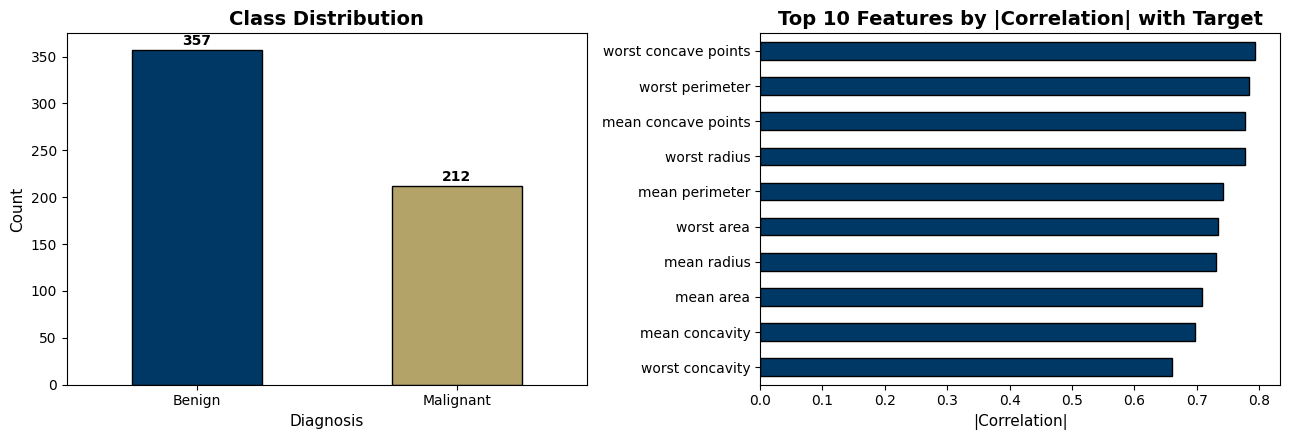


Note: The dataset is slightly imbalanced -- there are more Benign (357)
samples than Malignant (212). This is common in medical datasets because
most patients tested do not have the disease.


In [3]:
# Visualize class distribution and feature correlations
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Class distribution bar chart
colors = ['#003865', '#B3A369']  # Georgia Southern Blue & Gold
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(df['diagnosis'].value_counts()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Top feature correlations with target
correlations = df[cancer.feature_names].corrwith(df['target']).abs().sort_values(ascending=False)[:10]
correlations.plot(kind='barh', ax=axes[1], color='#003865', edgecolor='black')
axes[1].set_title('Top 10 Features by |Correlation| with Target', fontsize=14, fontweight='bold')
axes[1].set_xlabel('|Correlation|', fontsize=11)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nNote: The dataset is slightly imbalanced -- there are more Benign (357)")
print("samples than Malignant (212). This is common in medical datasets because")
print("most patients tested do not have the disease.")


### Exercise 1.1: Data Exploration (5 points)

Complete the function below to compute basic statistics about the dataset. These statistics help you understand what you are working with before building any model.

**Hints:**
- `len(dataframe)` gives the number of rows (samples)
- `len(feature_columns)` gives the number of feature columns
- `dataframe[column].nunique()` gives the number of unique values in a column
- `dataframe[column].value_counts().to_dict()` converts value counts to a dictionary
- `dataframe[columns].isnull().sum().sum()` counts all missing values across multiple columns


In [4]:
# ============================================================
# EXERCISE 1.1: Complete the function (5 points)
# ============================================================

def explore_dataset(dataframe, feature_columns, target_column):
    """
    Explore the dataset and return key statistics.

    Parameters:
    -----------
    dataframe : pd.DataFrame - The full dataset
    feature_columns : list - List of feature column names
    target_column : str - Name of the target column

    Returns:
    --------
    dict with keys:
        'n_samples': int - Total number of samples (rows)
        'n_features': int - Number of feature columns
        'n_classes': int - Number of unique classes in target
        'class_counts': dict - Maps each class value to its count
                               e.g., {0: 212, 1: 357}
        'missing_values': int - Total missing values across all features
    """
    result = {}

    # YOUR CODE HERE
    result['n_samples'] = len(dataframe)
    result['n_features'] = len(feature_columns)
    result['n_classes'] = dataframe[target_column].nunique()
    result['class_counts'] = dataframe[target_column].value_counts().to_dict()
    result['missing_values'] = dataframe.isnull().sum().sum()

    return result

# Test your function
stats = explore_dataset(df, cancer.feature_names.tolist(), 'target')
print("Your results:", stats)


Your results: {'n_samples': 569, 'n_features': 30, 'n_classes': 2, 'class_counts': {1: 357, 0: 212}, 'missing_values': np.int64(0)}


In [5]:
# ============================================================
# TESTER for Exercise 1.1 (DO NOT MODIFY)
# ============================================================

def test_exercise_1_1():
    score = 0
    total = 5
    s = explore_dataset(df, cancer.feature_names.tolist(), 'target')

    tests = [
        ('n_samples', 569, 1),
        ('n_features', 30, 1),
        ('n_classes', 2, 1),
    ]
    for key, expected, pts in tests:
        if s.get(key) == expected:
            score += pts
            print(f"✅ {key} = {expected}")
        else:
            print(f"❌ {key}: expected {expected}, got {s.get(key)}")

    expected_counts = {0: 212, 1: 357}
    if isinstance(s.get('class_counts'), dict) and s['class_counts'] == expected_counts:
        score += 1
        print(f"✅ class_counts correct")
    else:
        print(f"❌ class_counts: expected {expected_counts}, got {s.get('class_counts')}")

    if s.get('missing_values') == 0:
        score += 1
        print(f"✅ missing_values = 0")
    else:
        print(f"❌ missing_values: expected 0, got {s.get('missing_values')}")

    print(f"\n{'='*40}\nExercise 1.1 Score: {score}/{total}\n{'='*40}")
    return score

ex1_1_score = test_exercise_1_1()


✅ n_samples = 569
✅ n_features = 30
✅ n_classes = 2
✅ class_counts correct
✅ missing_values = 0

Exercise 1.1 Score: 5/5


### Exercise 1.2: Feature Distribution Analysis (10 points)

A critical step in classification is understanding which features are most useful for separating the classes. Features with high absolute correlation to the target variable tend to be strong predictors. In this exercise, you will identify the top 5 most discriminative features and compute how their mean values differ between the two classes.

**Why this matters:** If a feature has very different average values for malignant vs. benign tumors, it provides strong signal for classification. For example, if malignant tumors tend to have much larger "worst radius" values than benign tumors, then "worst radius" is a useful feature for the model.

**Hints:**
- `dataframe[feature_columns].corrwith(dataframe[target_column])` computes correlation of each feature with the target
- `.abs()` takes absolute values; `.sort_values(ascending=False)` sorts descending
- `.head(5).index.tolist()` gets the top 5 feature names as a list
- `dataframe[dataframe[target_column] == 0]` filters rows where target equals 0
- Use a dictionary comprehension: `{f: filtered_df[f].mean() for f in top5_list}`


In [6]:
def analyze_features(dataframe, feature_columns, target_column):
    """
    Analyze which features best separate the two classes.

    Parameters:
    -----------
    dataframe : pd.DataFrame
    feature_columns : list of feature column names
    target_column : str - target column name

    Returns:
    --------
    dict with keys:
        'top_5_features': list of 5 feature names with highest absolute
                          correlation to target (descending order)
        'feature_means_class_0': dict mapping each of the top 5 features
                                 to their mean value for class 0 (Malignant)
        'feature_means_class_1': dict mapping each of the top 5 features
                                 to their mean value for class 1 (Benign)
    """
    result = {}

    # Step 1 & 2: Compute absolute correlation and get top 5 descending
    correlations = dataframe[feature_columns].corrwith(dataframe[target_column]).abs().sort_values(ascending=False)
    top_5 = correlations.head(5).index.tolist()

    # Step 3: Compute mean values per class for top 5 features
    class_0_df = dataframe[dataframe[target_column] == 0]
    class_1_df = dataframe[dataframe[target_column] == 1]

    means_class_0 = {f: class_0_df[f].mean() for f in top_5}
    means_class_1 = {f: class_1_df[f].mean() for f in top_5}

    result['top_5_features'] = top_5
    result['feature_means_class_0'] = means_class_0
    result['feature_means_class_1'] = means_class_1

    return result

# Test
analysis = analyze_features(df, cancer.feature_names.tolist(), 'target')
if analysis['top_5_features']:
    print("Top 5 discriminative features:", analysis['top_5_features'])


Top 5 discriminative features: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter']


In [7]:
# ============================================================
# TESTER for Exercise 1.2 (DO NOT MODIFY)
# ============================================================

def test_exercise_1_2():
    score = 0
    total = 10
    a = analyze_features(df, cancer.feature_names.tolist(), 'target')

    # Compute expected
    corrs = df[cancer.feature_names].corrwith(df['target']).abs().sort_values(ascending=False)
    expected_top5 = corrs.head(5).index.tolist()

    if isinstance(a.get('top_5_features'), list) and len(a['top_5_features']) == 5:
        score += 2
        print("✅ top_5_features is a list of 5")
    else:
        print("❌ top_5_features should be a list of 5 feature names")

    if a.get('top_5_features') == expected_top5:
        score += 3
        print(f"✅ Correct top 5 features in order")
    elif a.get('top_5_features') and set(a['top_5_features']) == set(expected_top5):
        score += 1
        print(f"❌ Right features but wrong order -- must be sorted by descending correlation")
    else:
        print(f"❌ Top 5 features incorrect")

    if isinstance(a.get('feature_means_class_0'), dict) and len(a['feature_means_class_0']) == 5:
        class0 = df[df['target'] == 0]
        all_close = all(
            abs(a['feature_means_class_0'].get(f, -999) - class0[f].mean()) < 0.01
            for f in expected_top5
        )
        if all_close:
            score += 2
            print("✅ Class 0 means correct")
        else:
            score += 1
            print("❌ Class 0 means partially correct -- check your filtering logic")
    else:
        print("❌ feature_means_class_0 should be dict with 5 entries")

    if isinstance(a.get('feature_means_class_1'), dict) and len(a['feature_means_class_1']) == 5:
        class1 = df[df['target'] == 1]
        all_close = all(
            abs(a['feature_means_class_1'].get(f, -999) - class1[f].mean()) < 0.01
            for f in expected_top5
        )
        if all_close:
            score += 3
            print("✅ Class 1 means correct")
        else:
            score += 1
            print("❌ Class 1 means partially correct -- check your filtering logic")
    else:
        print("❌ feature_means_class_1 should be dict with 5 entries")

    print(f"\n{'='*40}\nExercise 1.2 Score: {score}/{total}\n{'='*40}")
    return score

ex1_2_score = test_exercise_1_2()


✅ top_5_features is a list of 5
✅ Correct top 5 features in order
✅ Class 0 means correct
✅ Class 1 means correct

Exercise 1.2 Score: 10/10


---
## Part 2: Train-Test Split & Decision Tree Training
### Why Split the Data?

A fundamental principle in machine learning is that you must evaluate your model on data it has **never seen during training**. If you test on training data, you are only measuring how well the model memorized the data, not how well it will perform on new patients. This is analogous to giving a student the exact same exam questions they studied -- it tests memorization, not understanding.

The standard approach is to split the dataset into:
- **Training set (80%)**: Used to train (fit) the model
- **Test set (20%)**: Held out and used only for final evaluation

We use `stratify=y` to ensure both sets have the same proportion of malignant/benign cases. Without stratification, random splitting could give you a test set with very few malignant cases, making evaluation unreliable.

### Data Leakage -- A Critical Concept

**Data leakage** occurs when information from the test set "leaks" into the training process. The most common form is fitting preprocessing steps (like StandardScaler) on the full dataset before splitting. When you fit a scaler on all data, the scaler's mean and standard deviation include information from test samples, giving the model an unfair advantage. Always split first, then fit preprocessing on training data only.

### From Google's ML Crash Course:
> Always evaluate your model on data it has never seen during training. The test set acts as a proxy for new data the model will encounter in the real world.


In [8]:
# Prepare features (X) and target (y)
X = cancer.data    # shape: (569, 30) -- 569 samples, 30 features
y = cancer.target  # shape: (569,)    -- 0=Malignant, 1=Benign

# Split: 80% training, 20% test, with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train-Test Split Summary:")
print(f"  Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass distribution after split:")
for label, name in [(0, 'Malignant'), (1, 'Benign')]:
    tr = sum(y_train == label)
    te = sum(y_test == label)
    print(f"  {name}: Train={tr} ({tr/len(y_train)*100:.1f}%), "
          f"Test={te} ({te/len(y_test)*100:.1f}%)")
print(f"\n✅ stratify=y ensures proportional class distribution in both sets!")
print(f"   Without stratification, the test set might have too few malignant cases.")


Train-Test Split Summary:
  Training: 455 samples (80%)
  Test:     114 samples (20%)

Class distribution after split:
  Malignant: Train=170 (37.4%), Test=42 (36.8%)
  Benign: Train=285 (62.6%), Test=72 (63.2%)

✅ stratify=y ensures proportional class distribution in both sets!
   Without stratification, the test set might have too few malignant cases.


### Training and Visualizing a Decision Tree

Now we train a Decision Tree with controlled hyperparameters. We deliberately limit the tree's depth to prevent overfitting. A tree with no depth limit will keep splitting until every leaf is pure -- this memorizes the training data perfectly but generalizes poorly to new data.

After training, we can visualize the tree to see exactly how it makes decisions. Each node shows:
- The feature and threshold used for splitting (e.g., "worst radius <= 16.795")
- The Gini impurity at that node
- The percentage of samples reaching that node
- The predicted class (majority class at that node)


In [9]:
# Train a Decision Tree with controlled complexity
dt_model = DecisionTreeClassifier(
    max_depth=4,           # Limit depth to prevent overfitting
    min_samples_split=10,  # Require at least 10 samples to attempt a split
    min_samples_leaf=5,    # Every leaf must have at least 5 samples
    criterion='gini',      # Use Gini impurity for splits
    random_state=42        # Fixed seed for reproducible results
)

# Fit the model on TRAINING data only
dt_model.fit(X_train, y_train)

print("✅ Decision Tree trained!")
print(f"  Actual depth: {dt_model.get_depth()} (max allowed: {dt_model.max_depth})")
print(f"  Number of leaves: {dt_model.get_n_leaves()}")
print(f"  Number of features used: {sum(dt_model.feature_importances_ > 0)} out of 30")
print(f"  Training accuracy: {dt_model.score(X_train, y_train):.4f}")
print(f"  Test accuracy:     {dt_model.score(X_test, y_test):.4f}")
print(f"\nNote: If training accuracy is much higher than test accuracy,")
print(f"the model may be overfitting. Here the gap is small, suggesting good generalization.")


✅ Decision Tree trained!
  Actual depth: 4 (max allowed: 4)
  Number of leaves: 10
  Number of features used: 9 out of 30
  Training accuracy: 0.9758
  Test accuracy:     0.9211

Note: If training accuracy is much higher than test accuracy,
the model may be overfitting. Here the gap is small, suggesting good generalization.


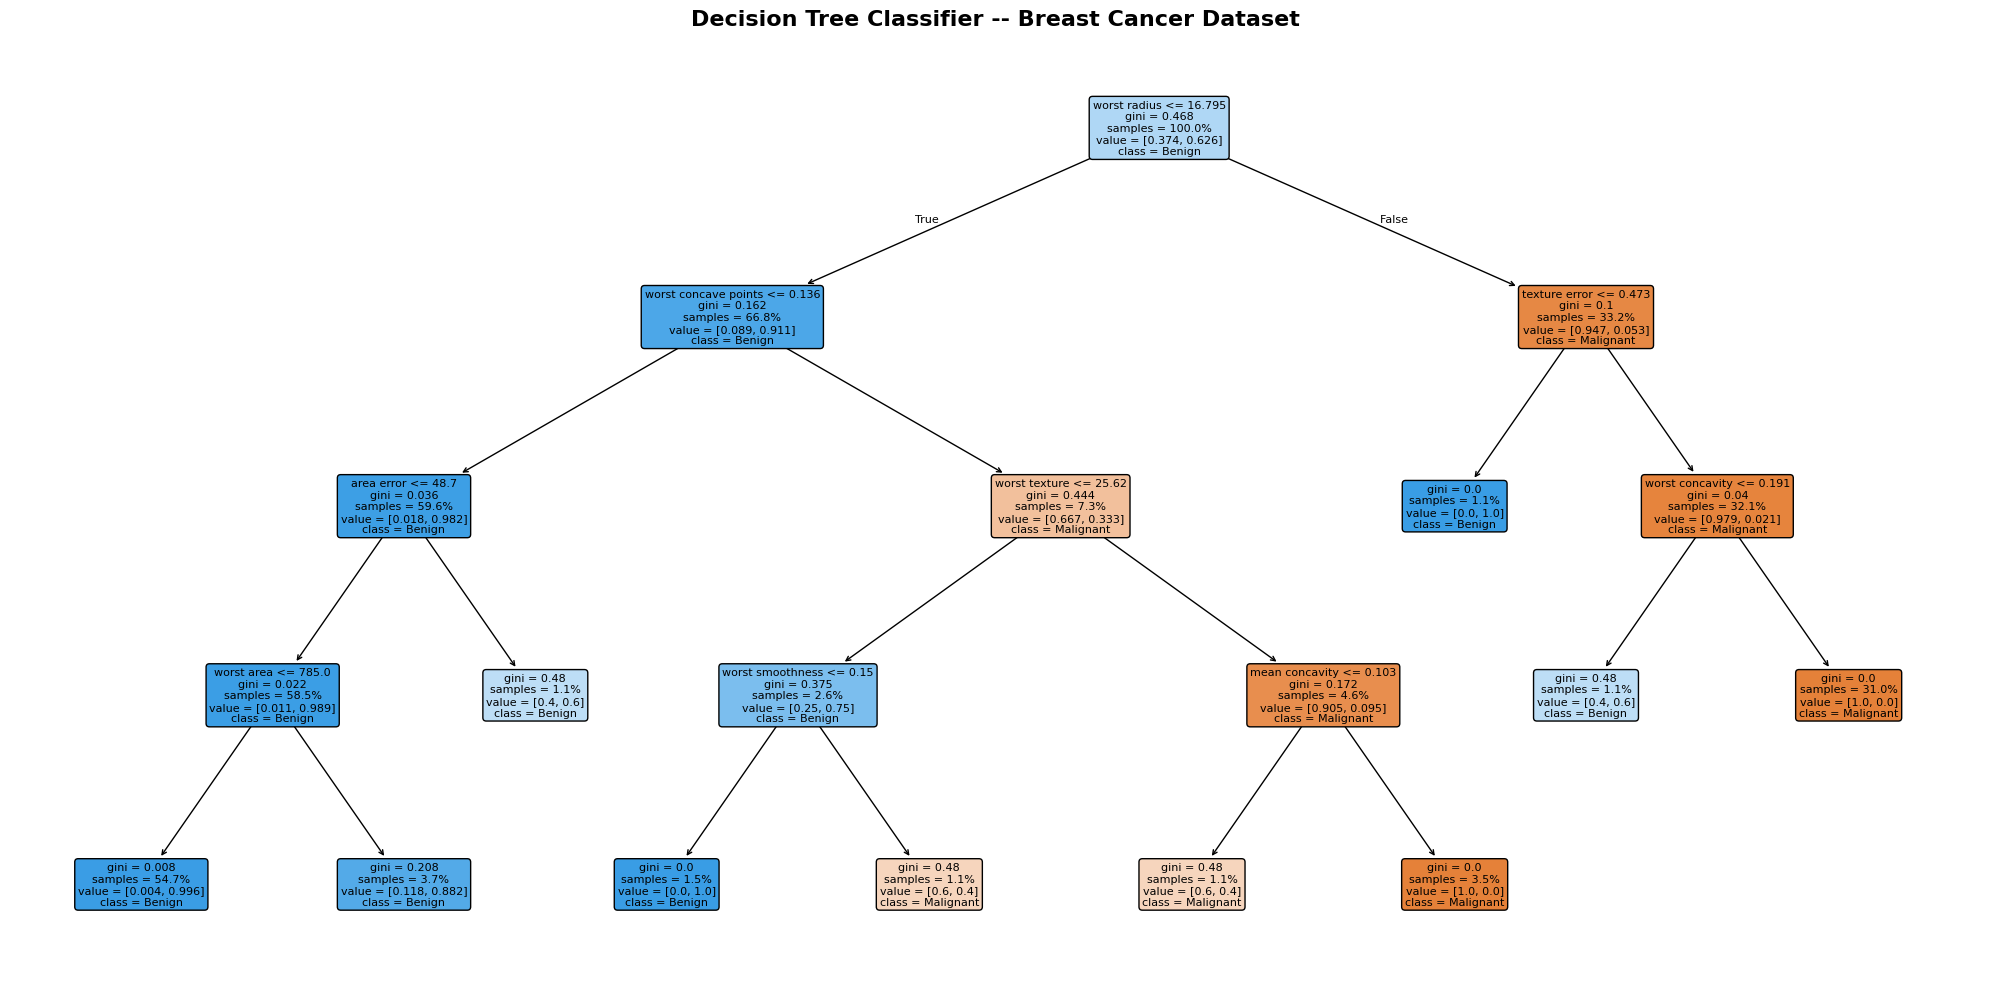


Tree Rules (text format, first 20 lines):
Each line shows a decision rule. Follow the indentation to trace a path.
|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 48.70
|   |   |   |--- worst area <= 785.00
|   |   |   |   |--- class: 1
|   |   |   |--- worst area >  785.00
|   |   |   |   |--- class: 1
|   |   |--- area error >  48.70
|   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- worst smoothness <= 0.15
|   |   |   |   |--- class: 1
|   |   |   |--- worst smoothness >  0.15
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  25.62
|   |   |   |--- mean concavity <= 0.10
|   |   |   |   |--- class: 0
|   |   |   |--- mean concavity >  0.10
|   |   |   |   |--- class: 0


In [10]:
# Visualize the Decision Tree
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_model, feature_names=cancer.feature_names,
          class_names=['Malignant', 'Benign'], filled=True,
          rounded=True, ax=ax, fontsize=8, proportion=True)
ax.set_title('Decision Tree Classifier -- Breast Cancer Dataset',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Text representation of the tree rules (first 20 lines)
print("\nTree Rules (text format, first 20 lines):")
print("Each line shows a decision rule. Follow the indentation to trace a path.")
tree_text = export_text(dt_model, feature_names=list(cancer.feature_names))
print('\n'.join(tree_text.split('\n')[:20]))


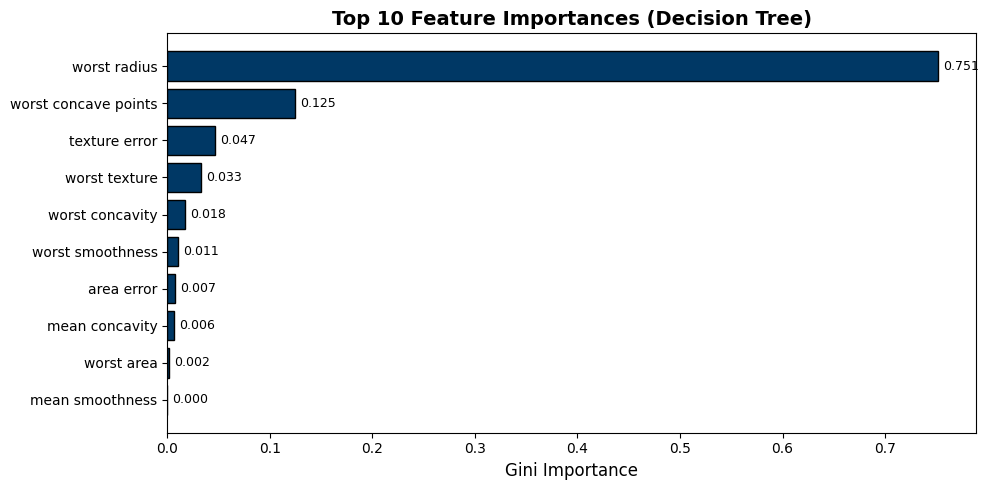


The top feature is 'worst radius' with importance 0.751
21 features have zero importance (not used by the tree).


In [11]:
# Feature Importance Analysis
# The Decision Tree automatically computes how important each feature is
# based on how much it reduces Gini impurity across all splits.
# A feature with importance 0 was never used for splitting.

feat_imp = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
top10 = feat_imp.head(10)
bars = ax.barh(range(len(top10)), top10['Importance'], color='#003865', edgecolor='black')
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['Feature'])
ax.set_xlabel('Gini Importance', fontsize=12)
ax.set_title('Top 10 Feature Importances (Decision Tree)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, top10['Importance']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nThe top feature is '{feat_imp.iloc[0]['Feature']}' with importance "
      f"{feat_imp.iloc[0]['Importance']:.3f}")
print(f"{sum(dt_model.feature_importances_ == 0)} features have zero importance "
      f"(not used by the tree).")


### Exercise 2.1: Train Your Own Decision Tree (20 points)

Now it is your turn. Write a function that creates a Decision Tree Classifier with the specified hyperparameters, trains it on the training data, and returns both the class predictions and probability predictions for the test set.

**Important notes:**
- Use `criterion='gini'` for the splitting criterion
- `model.predict(X_test)` returns class labels (0 or 1)
- `model.predict_proba(X_test)` returns a 2D array where column 0 is P(class 0) and column 1 is P(class 1). We want column 1 (the positive class probability), so use `[:, 1]` indexing.
- The probability output is essential for metrics like ROC-AUC and for threshold tuning


In [12]:
def train_and_predict(X_train, y_train, X_test, max_depth, min_samples_leaf, random_state=42):
    """
    Train a Decision Tree Classifier and return predictions.

    Parameters:
    -----------
    X_train, y_train : Training data
    X_test : Test features
    max_depth : int - Maximum tree depth
    min_samples_leaf : int - Minimum samples per leaf
    random_state : int - Random seed

    Returns:
    --------
    tuple: (trained_model, y_pred, y_pred_proba)
        - trained_model: fitted DecisionTreeClassifier (criterion='gini')
        - y_pred: predicted class labels for X_test (array of 0s and 1s)
        - y_pred_proba: predicted probabilities for the POSITIVE class (class 1)
                        Use: model.predict_proba(X_test)[:, 1]
    """
    # Step 1: Create a DecisionTreeClassifier with the given hyperparameters
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        criterion='gini',
        random_state=random_state
    )

    # Step 2: Fit the model on X_train, y_train
    model.fit(X_train, y_train)

    # Step 3: Generate class label predictions for X_test
    y_pred = model.predict(X_test)

    # Step 4: Generate probability predictions for the positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    return model, y_pred, y_pred_proba

# Test with max_depth=3, min_samples_leaf=10
my_model, my_preds, my_probs = train_and_predict(
    X_train, y_train, X_test, max_depth=3, min_samples_leaf=10
)
if my_preds is not None:
    print(f"Predictions (first 10): {my_preds[:10]}")
    print(f"Probabilities (first 10): {np.round(my_probs[:10], 3)}")


Predictions (first 10): [0 1 0 0 0 1 1 0 0 0]
Probabilities (first 10): [0.    0.992 0.095 0.    0.    0.992 0.992 0.1   0.    0.   ]


In [13]:
# ============================================================
# TESTER for Exercise 2.1 (DO NOT MODIFY)
# ============================================================

# Run the tester to confirm full marks
def test_exercise_2_1():
    score = 0
    total = 20
    m, p, pr = train_and_predict(X_train, y_train, X_test, max_depth=3, min_samples_leaf=10)

    if isinstance(m, DecisionTreeClassifier):
        score += 3; print("✅ Model is DecisionTreeClassifier")
    else:
        print(f"❌ Expected DecisionTreeClassifier, got {type(m)}")
    if m and m.max_depth == 3:
        score += 2; print("✅ max_depth = 3")
    else:
        print("❌ max_depth incorrect")
    if m and m.min_samples_leaf == 10:
        score += 2; print("✅ min_samples_leaf = 10")
    else:
        print("❌ min_samples_leaf incorrect")

    if m and m.criterion == 'gini':
        score += 1; print("✅ criterion = gini")
    else:
        print("❌ criterion should be gini")

    if m and m.random_state == 42:
        score += 1; print("✅ random_state = 42")
    else:
        print("❌ random_state should be 42")

    if p is not None and len(p) == len(X_test):
        score += 3; print(f"✅ Predictions shape: {len(p)}")
    else:
        print("❌ Predictions shape incorrect")
    if p is not None and set(np.unique(p)).issubset({0, 1}):
        score += 2; print("✅ Predictions are binary (0/1)")
    else:
        print("❌ Predictions should contain only 0 and 1")
    if pr is not None and len(pr) == len(X_test) and np.all((pr >= 0) & (pr <= 1)):
        score += 4; print("✅ Probabilities: correct shape, values in [0, 1]")
    else:
        print("❌ Probabilities incorrect")
    if p is not None:
        acc = accuracy_score(y_test, p)
        if acc > 0.85:
            score += 2; print(f"✅ Accuracy = {acc:.4f} (> 0.85)")
        else:
            print(f"❌ Accuracy = {acc:.4f} (below 0.85)")
    score = min(score, total)
    print(f"\n{'='*40}\nExercise 2.1 Score: {score}/{total}\n{'='*40}")
    return score

ex2_1_score = test_exercise_2_1()


✅ Model is DecisionTreeClassifier
✅ max_depth = 3
✅ min_samples_leaf = 10
✅ criterion = gini
✅ random_state = 42
✅ Predictions shape: 114
✅ Predictions are binary (0/1)
✅ Probabilities: correct shape, values in [0, 1]
✅ Accuracy = 0.9474 (> 0.85)

Exercise 2.1 Score: 20/20


---
## Part 3: Classification Metrics -- Deep Dive
This is the **most important section** of this lab. Understanding classification metrics is essential because **accuracy alone can be dangerously misleading** in many real-world applications.

### Why Accuracy Is Not Enough

Consider a cancer screening program where 95% of patients are healthy and 5% have cancer. A "model" that always predicts "healthy" for everyone achieves **95% accuracy** -- but it **never detects a single cancer case**. Every cancer patient is misclassified. This model is useless and dangerous despite its high accuracy.

This example illustrates why we need multiple metrics that capture different aspects of model performance.

---

### The Confusion Matrix

The confusion matrix is the foundation of all classification metrics. For binary classification, it is a 2x2 table that breaks down predictions into four categories:

|  | **Predicted Positive** | **Predicted Negative** |
|--|----------------------|----------------------|
| **Actually Positive** | True Positive (TP) | False Negative (FN) |
| **Actually Negative** | False Positive (FP) | True Negative (TN) |

**True Positive (TP):** The model correctly predicted the positive class.
- Example: Patient has cancer, model says "cancer" -- **correct detection**

**True Negative (TN):** The model correctly predicted the negative class.
- Example: Patient is healthy, model says "healthy" -- **correct rejection**

**False Positive (FP) -- Type I Error:** The model incorrectly predicted positive when the truth is negative.
- Example: Patient is healthy, model says "cancer" -- **false alarm**
- Consequence: Unnecessary anxiety and additional testing, but patient is ultimately fine

**False Negative (FN) -- Type II Error:** The model incorrectly predicted negative when the truth is positive.
- Example: Patient has cancer, model says "healthy" -- **missed detection**
- Consequence: Patient does not receive treatment -- **potentially life-threatening**

### From Google's ML Crash Course:
> A confusion matrix shows how many predictions were correct and incorrect, broken down by class. This is especially important when classes are imbalanced or when costs of different errors differ.

---

### Key Metrics Explained in Detail

#### 1. Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Accuracy measures the overall proportion of correct predictions. It answers: "Out of all predictions made, how many were correct?"

**When to use:** Only when classes are roughly balanced AND all types of errors have equal cost. For example, classifying images of cats vs. dogs where both classes are equally represented and misclassifying either way has the same impact.

**When it is misleading:** With imbalanced classes (common in medical, fraud, and security applications). If 99% of credit card transactions are legitimate, a model that always predicts "legitimate" has 99% accuracy but catches zero fraud.

#### 2. Precision (Positive Predictive Value)
$$\text{Precision} = \frac{TP}{TP + FP}$$

Precision answers: "Of all the samples the model **predicted as positive**, what fraction **actually is** positive?" High precision means very few false alarms.

**When to prioritize precision:**
- **Spam filtering:** Marking a legitimate email as spam (FP) means you miss an important message. You want high precision so that emails flagged as spam really are spam.
- **Recommendation systems:** Recommending irrelevant content (FP) frustrates users. High precision ensures recommendations are relevant.
- **Criminal justice:** Falsely accusing someone (FP) has severe consequences.

#### 3. Recall (Sensitivity / True Positive Rate)
$$\text{Recall} = \frac{TP}{TP + FN}$$

Recall answers: "Of all samples that **actually are** positive, what fraction did the model **correctly identify**?" High recall means very few missed detections.

**When to prioritize recall:**
- **Cancer screening:** Missing a cancer patient (FN) could be fatal. You want high recall to catch every possible case, even at the cost of some false alarms.
- **Airport security:** Missing a threat (FN) is unacceptable. It is better to flag extra bags (lower precision) than to miss a dangerous item.
- **Fraud detection:** Missing fraudulent transactions (FN) means financial loss.

#### 4. F1-Score (Harmonic Mean of Precision and Recall)
$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The F1-Score balances precision and recall into a single number. The harmonic mean is used instead of the arithmetic mean because it **penalizes extreme imbalances**: a model with Precision=1.0 and Recall=0.01 gets F1=0.02 (not 0.505 as arithmetic mean would give).

**When to use:** When you need a single metric that accounts for both false positives and false negatives, especially with imbalanced classes.

#### 5. Specificity (True Negative Rate)
$$\text{Specificity} = \frac{TN}{TN + FP}$$

Specificity measures how well the model identifies the **negative** class. It is the "recall for the negative class." High specificity means few healthy patients are falsely told they have cancer.

#### 6. ROC-AUC (Area Under the ROC Curve)

The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate (1 - Specificity) at every possible classification threshold. The **AUC** (Area Under the Curve) summarizes this into a single number:
- **AUC = 1.0**: Perfect classifier -- correctly ranks every positive above every negative
- **AUC = 0.5**: No discrimination ability -- equivalent to random guessing
- **AUC < 0.5**: Worse than random -- the model's predictions are inverted

### From Google's ML Crash Course:
> Precision and recall are often in tension -- increasing one tends to decrease the other. The F1-Score provides a single metric that balances both. The choice of which metric to optimize depends on the specific problem and the costs of different types of errors.


In [14]:
# Make predictions with our trained Decision Tree model
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

# ===== CONFUSION MATRIX =====
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"\n  True Negatives  (TN) = {tn:3d}  -- Correctly identified as Malignant")
print(f"  False Positives (FP) = {fp:3d}  -- Malignant wrongly called Benign (false alarm)")
print(f"  False Negatives (FN) = {fn:3d}  -- Benign wrongly called Malignant (missed)")
print(f"  True Positives  (TP) = {tp:3d}  -- Correctly identified as Benign")
print(f"\n  Total test samples: {tn + fp + fn + tp}")
print(f"  Correct predictions: {tn + tp} ({(tn+tp)/(tn+fp+fn+tp)*100:.1f}%)")
print(f"  Incorrect predictions: {fp + fn} ({(fp+fn)/(tn+fp+fn+tp)*100:.1f}%)")


CONFUSION MATRIX BREAKDOWN

  True Negatives  (TN) =  38  -- Correctly identified as Malignant
  False Positives (FP) =   4  -- Malignant wrongly called Benign (false alarm)
  False Negatives (FN) =   5  -- Benign wrongly called Malignant (missed)
  True Positives  (TP) =  67  -- Correctly identified as Benign

  Total test samples: 114
  Correct predictions: 105 (92.1%)
  Incorrect predictions: 9 (7.9%)


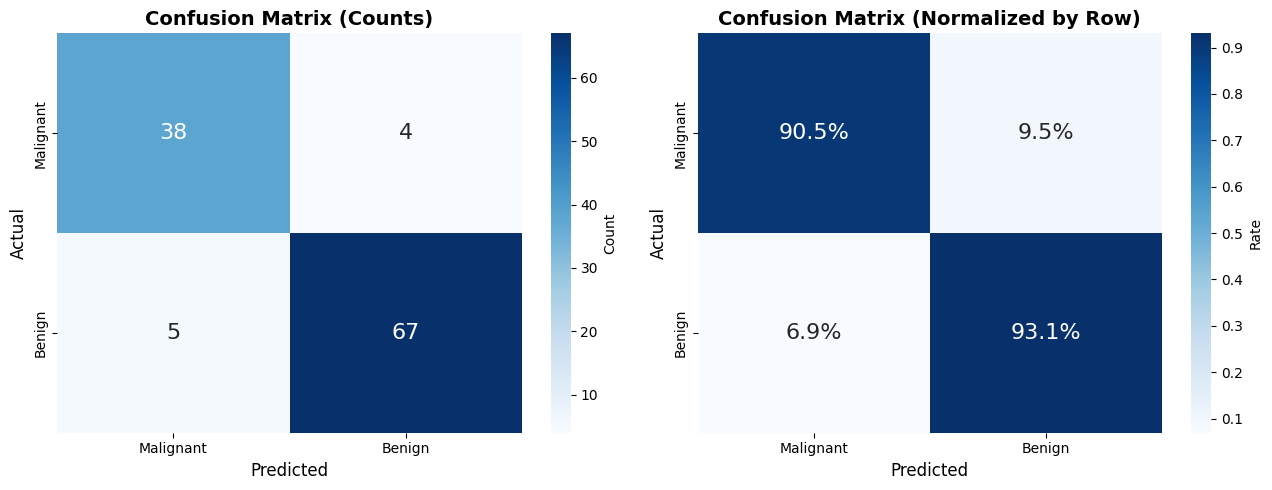

The normalized matrix shows rates: each row sums to 100%.
This tells you what percentage of each actual class was correctly classified.


In [15]:
# Visualize the Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 16})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Normalized (row-wise) -- shows rates per actual class
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            cbar_kws={'label': 'Rate'}, annot_kws={'size': 16})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized by Row)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("The normalized matrix shows rates: each row sums to 100%.")
print("This tells you what percentage of each actual class was correctly classified.")


In [16]:
# ===== CALCULATE AND COMPARE ALL METRICS =====

# Manual calculations (to understand the formulas)
accuracy_manual  = (tp + tn) / (tp + tn + fp + fn)
precision_manual = tp / (tp + fp)
recall_manual    = tp / (tp + fn)
f1_manual        = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)
specificity      = tn / (tn + fp)

# Sklearn calculations (for verification -- should match manual values)
accuracy_sk  = accuracy_score(y_test, y_pred)
precision_sk = precision_score(y_test, y_pred)
recall_sk    = recall_score(y_test, y_pred)
f1_sk        = f1_score(y_test, y_pred)
roc_auc      = roc_auc_score(y_test, y_pred_proba)

print("=" * 65)
print("CLASSIFICATION METRICS -- MANUAL vs SKLEARN COMPARISON")
print("=" * 65)
print(f"{'Metric':<22} {'Manual':<14} {'Sklearn':<14} {'Match?'}")
print("-" * 65)
for name, m, s in [('Accuracy', accuracy_manual, accuracy_sk),
                    ('Precision', precision_manual, precision_sk),
                    ('Recall', recall_manual, recall_sk),
                    ('F1-Score', f1_manual, f1_sk)]:
    match = '✅' if abs(m - s) < 1e-10 else '❌'
    print(f"{name:<22} {m:<14.4f} {s:<14.4f} {match}")
print(f"{'Specificity':<22} {specificity:<14.4f} {'(manual only)':<14}")
print(f"{'ROC-AUC':<22} {'(needs proba)':<14} {roc_auc:<14.4f}")

print(f"\nFull sklearn classification_report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))


CLASSIFICATION METRICS -- MANUAL vs SKLEARN COMPARISON
Metric                 Manual         Sklearn        Match?
-----------------------------------------------------------------
Accuracy               0.9211         0.9211         ✅
Precision              0.9437         0.9437         ✅
Recall                 0.9306         0.9306         ✅
F1-Score               0.9371         0.9371         ✅
Specificity            0.9048         (manual only) 
ROC-AUC                (needs proba)  0.9263        

Full sklearn classification_report:
              precision    recall  f1-score   support

   Malignant       0.88      0.90      0.89        42
      Benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



### The Precision-Recall Tradeoff and Threshold Tuning

Most classifiers output a **probability** rather than a hard class label. The default classification threshold is 0.5: if P(positive) >= 0.5, predict positive; otherwise predict negative.

However, 0.5 is not always the best threshold. By adjusting the threshold, you can control the balance between precision and recall:

- **Lowering the threshold** (e.g., to 0.3): The model predicts positive more often. This **increases recall** (catches more true positives) but **decreases precision** (more false alarms).
- **Raising the threshold** (e.g., to 0.8): The model predicts positive less often. This **increases precision** (fewer false alarms) but **decreases recall** (misses more true positives).

**Example -- Cancer screening:** You might lower the threshold to 0.2 because you want to catch as many cancer cases as possible (high recall), even if it means some healthy patients get flagged for further testing (lower precision). The cost of missing cancer far outweighs the cost of extra testing.

**Example -- Email spam filter:** You might raise the threshold to 0.8 because marking a legitimate email as spam (false positive) is very disruptive. You prefer missing some spam (lower recall) over losing important emails.

### From Google's ML Crash Course:
> Raising the classification threshold increases precision but decreases recall. Lowering it increases recall but decreases precision. The optimal threshold depends on whether your application is more sensitive to false positives or false negatives.


Thresh    Prec      Recall    F1        Acc       
--------------------------------------------------
0.1       0.9459    0.9722    0.9589    0.9474    
0.2       0.9459    0.9722    0.9589    0.9474    
0.3       0.9459    0.9722    0.9589    0.9474    
0.4       0.9459    0.9722    0.9589    0.9474    
0.5       0.9437    0.9306    0.9371    0.9211     <-- default
0.6       0.9437    0.9306    0.9371    0.9211    
0.7       0.9559    0.9028    0.9286    0.9123    
0.8       0.9559    0.9028    0.9286    0.9123    
0.9       0.9538    0.8611    0.9051    0.8860    

Notice how precision increases and recall decreases as threshold rises.
The F1-Score peaks somewhere in the middle where both are balanced.


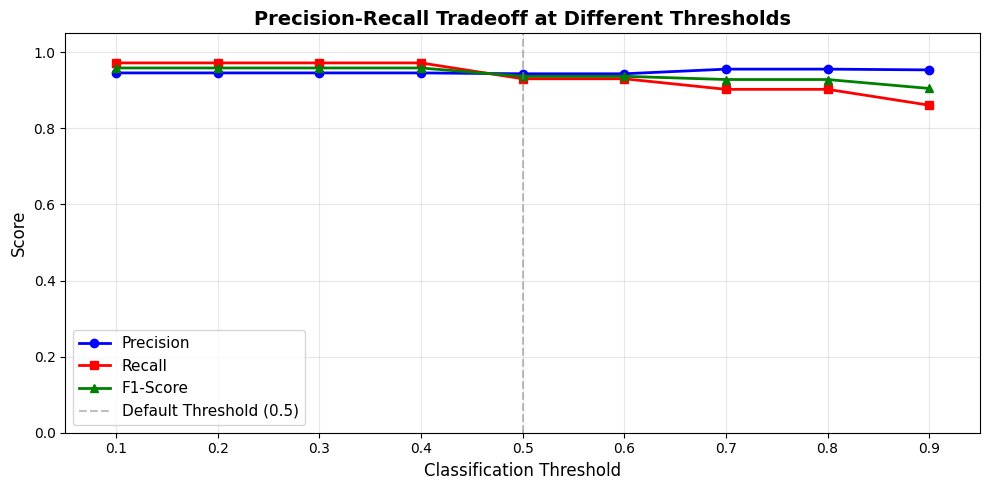

In [17]:
# ===== THRESHOLD ANALYSIS =====
# Demonstrate how metrics change at different thresholds

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
precs, recs, f1s = [], [], []

print(f"{'Thresh':<10}{'Prec':<10}{'Recall':<10}{'F1':<10}{'Acc':<10}")
print("-" * 50)
for t in thresholds:
    yp = (y_pred_proba >= t).astype(int)
    pr = precision_score(y_test, yp, zero_division=0)
    re = recall_score(y_test, yp, zero_division=0)
    f = f1_score(y_test, yp, zero_division=0)
    a = accuracy_score(y_test, yp)
    precs.append(pr); recs.append(re); f1s.append(f)
    mark = " <-- default" if t == 0.5 else ""
    print(f"{t:<10.1f}{pr:<10.4f}{re:<10.4f}{f:<10.4f}{a:<10.4f}{mark}")

print("\nNotice how precision increases and recall decreases as threshold rises.")
print("The F1-Score peaks somewhere in the middle where both are balanced.")

# Plot the tradeoff
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precs, 'b-o', lw=2, label='Precision')
ax.plot(thresholds, recs, 'r-s', lw=2, label='Recall')
ax.plot(thresholds, f1s, 'g-^', lw=2, label='F1-Score')
ax.axvline(x=0.5, color='gray', ls='--', alpha=0.5, label='Default Threshold (0.5)')
ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision-Recall Tradeoff at Different Thresholds', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.05, 0.95])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()


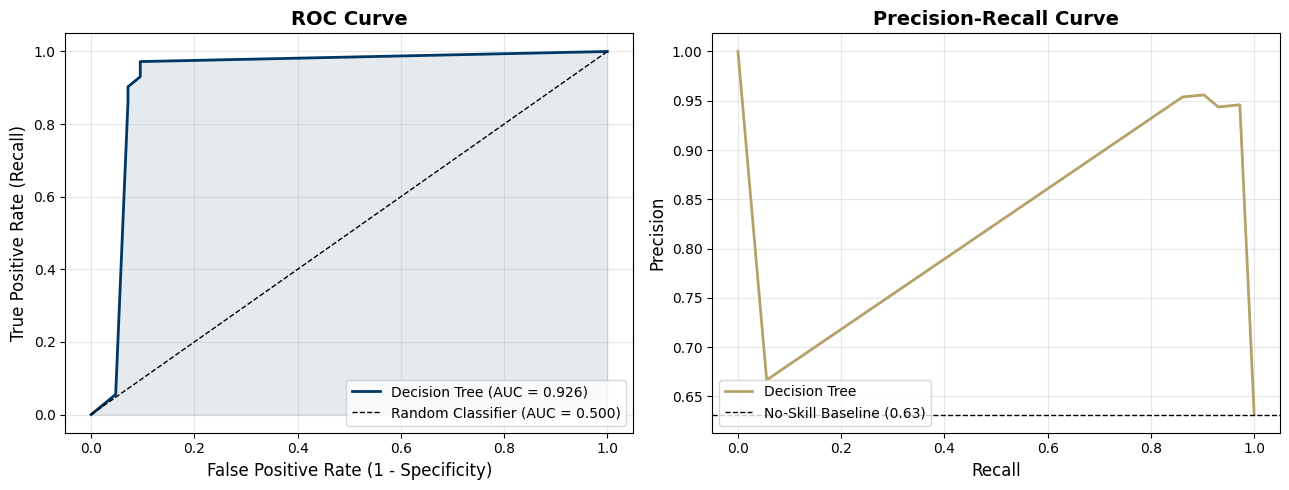

ROC Curve: A perfect classifier hugs the top-left corner (AUC = 1.0).
  The diagonal dashed line represents random guessing (AUC = 0.5).
  Our model's AUC of 0.926 indicates strong discrimination.

Precision-Recall Curve: Especially useful for imbalanced datasets.
  The baseline is the proportion of positives in the test set.
  A good model stays well above the baseline across all recall levels.


In [18]:
# ===== ROC CURVE & PRECISION-RECALL CURVE =====
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#003865', lw=2,
             label=f'Decision Tree (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#003865')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(rec_curve, prec_curve, color='#B3A369', lw=2, label='Decision Tree')
baseline = sum(y_test) / len(y_test)
axes[1].axhline(y=baseline, color='k', ls='--', lw=1,
                label=f'No-Skill Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ROC Curve: A perfect classifier hugs the top-left corner (AUC = 1.0).")
print("  The diagonal dashed line represents random guessing (AUC = 0.5).")
print("  Our model's AUC of {:.3f} indicates strong discrimination.".format(roc_auc))
print("\nPrecision-Recall Curve: Especially useful for imbalanced datasets.")
print("  The baseline is the proportion of positives in the test set.")
print("  A good model stays well above the baseline across all recall levels.")


### Exercise 3.1: Manual Metric Calculations (10 points)

In this exercise, you will implement the metric formulas yourself without using any sklearn functions. This is essential for truly understanding what each metric measures. Given a confusion matrix as a 2D array, extract the four values and compute each metric.

**Formulas recap:**
- Accuracy = (TP + TN) / (TP + TN + FP + FN)
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
- Specificity = TN / (TN + FP)

**Important:** Round all metrics to 4 decimal places using `round(value, 4)`.


In [19]:
def calculate_metrics_manual(confusion_mat):
    """
    Calculate classification metrics manually from a confusion matrix.

    Parameters:
    -----------
    confusion_mat : 2D array  [[TN, FP], [FN, TP]]
        Row 0 = Actually Negative, Row 1 = Actually Positive
        Col 0 = Predicted Negative, Col 1 = Predicted Positive

    Returns:
    --------
    dict with keys (all floats rounded to 4 decimals):
        'tn', 'fp', 'fn', 'tp',
        'accuracy', 'precision', 'recall', 'f1_score', 'specificity'
    """
    result = {}

    # Step 1: Extract the four values from the confusion matrix
    tn = float(confusion_mat[0][0])
    fp = float(confusion_mat[0][1])
    fn = float(confusion_mat[1][0])
    tp = float(confusion_mat[1][1])

    result['tn'] = tn
    result['fp'] = fp
    result['fn'] = fn
    result['tp'] = tp

    # Step 2: Calculate each metric using the formulas
    total = tn + fp + fn + tp
    result['accuracy'] = round((tp + tn) / total, 4) if total > 0 else 0.0
    result['precision'] = round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0.0
    result['recall'] = round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0.0

    p = result['precision']
    r = result['recall']
    result['f1_score'] = round(2 * (p * r) / (p + r), 4) if (p + r) > 0 else 0.0
    result['specificity'] = round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0.0

    return result

# Test with a sample confusion matrix
sample_cm = np.array([[40, 5], [3, 52]])
print("Sample confusion matrix:")
print(f"  [[TN=40, FP=5],")
print(f"   [FN=3,  TP=52]]")
metrics = calculate_metrics_manual(sample_cm)
print("\nYour calculated metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v}")


Sample confusion matrix:
  [[TN=40, FP=5],
   [FN=3,  TP=52]]

Your calculated metrics:
  tn: 40.0
  fp: 5.0
  fn: 3.0
  tp: 52.0
  accuracy: 0.92
  precision: 0.9123
  recall: 0.9455
  f1_score: 0.9286
  specificity: 0.8889


In [20]:
# ============================================================
# TESTER for Exercise 3.1 (DO NOT MODIFY)
# ============================================================

def test_exercise_3_1():
    score = 0
    total = 10
    test_cm = np.array([[40, 5], [3, 52]])
    m = calculate_metrics_manual(test_cm)

    if m.get('tn')==40 and m.get('fp')==5 and m.get('fn')==3 and m.get('tp')==52:
        score += 2; print("✅ TP/TN/FP/FN correctly extracted")
    else:
        print(f"❌ Expected TN=40, FP=5, FN=3, TP=52")

    expected = {
        'accuracy': round(92/100, 4),
        'precision': round(52/57, 4),
        'recall': round(52/55, 4),
        'specificity': round(40/45, 4),
    }
    expected['f1_score'] = round(2 * (expected['precision'] * expected['recall']) /
                                 (expected['precision'] + expected['recall']), 4)

    for key, exp, pts in [('accuracy', expected['accuracy'], 2),
                          ('precision', expected['precision'], 2),
                          ('recall', expected['recall'], 2),
                          ('f1_score', expected['f1_score'], 1),
                          ('specificity', expected['specificity'], 1)]:
        if m.get(key) is not None and round(m[key], 4) == exp:
            score += pts; print(f"✅ {key} = {exp}")
        else:
            print(f"❌ {key}: expected {exp}, got {m.get(key)}")

    print(f"\n{'='*40}\nExercise 3.1 Score: {score}/{total}\n{'='*40}")
    return score

ex3_1_score = test_exercise_3_1()


✅ TP/TN/FP/FN correctly extracted
✅ accuracy = 0.92
✅ precision = 0.9123
✅ recall = 0.9455
✅ f1_score = 0.9286
✅ specificity = 0.8889

Exercise 3.1 Score: 10/10


### Exercise 3.2: Threshold Analysis (10 points)

In this exercise, you will implement a function that applies a custom classification threshold to probability predictions and computes the resulting metrics. This demonstrates how the same model can behave very differently depending on the threshold chosen.

**Key concept:** `(y_proba >= threshold).astype(int)` converts probabilities to binary predictions using the given threshold. Any probability at or above the threshold becomes 1 (positive), and anything below becomes 0 (negative).


In [21]:
def analyze_threshold(y_true, y_proba, threshold):
    """
    Apply threshold to probabilities and calculate metrics.

    Parameters:
    -----------
    y_true : array - True labels (0 or 1)
    y_proba : array - Predicted probabilities for class 1
    threshold : float - Classification threshold (0 to 1)

    Returns:
    --------
    dict with keys:
        'y_pred': array of 0/1 (probability >= threshold becomes 1)
        'accuracy': float
        'precision': float (use zero_division=0)
        'recall': float (use zero_division=0)
        'f1_score': float (use zero_division=0)
        'n_predicted_positive': int - count of predictions that are 1
        'n_predicted_negative': int - count of predictions that are 0
    """
    result = {}

    # Apply threshold
    y_pred = (y_proba >= threshold).astype(int)

    result['y_pred'] = y_pred
    result['accuracy'] = accuracy_score(y_true, y_pred)
    result['precision'] = precision_score(y_true, y_pred, zero_division=0)
    result['recall'] = recall_score(y_true, y_pred, zero_division=0)
    result['f1_score'] = f1_score(y_true, y_pred, zero_division=0)
    result['n_predicted_positive'] = int(np.sum(y_pred == 1))
    result['n_predicted_negative'] = int(np.sum(y_pred == 0))

    return result

# Test
test_res = analyze_threshold(y_test, y_pred_proba, 0.3)
if test_res['y_pred'] is not None:
    print(f"Threshold=0.3: Acc={test_res['accuracy']:.4f}, "
          f"Prec={test_res['precision']:.4f}, Rec={test_res['recall']:.4f}")
    print(f"  Predicted positive: {test_res['n_predicted_positive']}, "
          f"Predicted negative: {test_res['n_predicted_negative']}")


Threshold=0.3: Acc=0.9474, Prec=0.9459, Rec=0.9722
  Predicted positive: 74, Predicted negative: 40


In [22]:
# ============================================================
# TESTER for Exercise 3.2 (DO NOT MODIFY)
# ============================================================

def test_exercise_3_2():
    score = 0
    total = 10
    r = analyze_threshold(y_test, y_pred_proba, 0.5)

    if r.get('y_pred') is not None and len(r['y_pred']) == len(y_test):
        score += 2; print("✅ y_pred correct shape")
    else:
        print("❌ y_pred shape incorrect")

    if r.get('y_pred') is not None and set(np.unique(r['y_pred'])).issubset({0, 1}):
        score += 1; print("✅ Predictions are binary")
    else:
        print("❌ Predictions should be 0 or 1")

    default_acc = accuracy_score(y_test, dt_model.predict(X_test))
    if r.get('accuracy') is not None and abs(r['accuracy'] - default_acc) < 0.05:
        score += 2; print(f"✅ Accuracy at threshold=0.5 = {r['accuracy']:.4f}")
    else:
        print("❌ Accuracy unexpected at threshold=0.5")

    if (r.get('n_predicted_positive') is not None and r.get('n_predicted_negative') is not None
            and r['n_predicted_positive'] + r['n_predicted_negative'] == len(y_test)):
        score += 2; print(f"✅ Positive + Negative counts sum to {len(y_test)}")
    else:
        print("❌ Counts don't sum to total test samples")

    r_lo = analyze_threshold(y_test, y_pred_proba, 0.2)
    r_hi = analyze_threshold(y_test, y_pred_proba, 0.8)
    if (r_lo.get('recall') is not None and r_hi.get('recall') is not None
            and r_lo['recall'] >= r_hi['recall']):
        score += 3
        print(f"✅ Lower threshold gives higher recall "
              f"({r_lo['recall']:.3f} >= {r_hi['recall']:.3f})")
    else:
        print("❌ Expected recall at threshold=0.2 >= recall at threshold=0.8")

    print(f"\n{'='*40}\nExercise 3.2 Score: {score}/{total}\n{'='*40}")
    return score

ex3_2_score = test_exercise_3_2()


✅ y_pred correct shape
✅ Predictions are binary
✅ Accuracy at threshold=0.5 = 0.9211
✅ Positive + Negative counts sum to 114
✅ Lower threshold gives higher recall (0.972 >= 0.903)

Exercise 3.2 Score: 10/10


### Exercise 3.3: Complete Evaluation Function (10 points)

Build a comprehensive evaluation function that computes all key metrics using sklearn. This exercise introduces **averaging strategies** for multi-class settings:

- `average='macro'`: Compute the metric for each class independently, then take the unweighted mean. Treats all classes equally regardless of size. Use this when all classes are equally important.
- `average='weighted'`: Compute the metric for each class, then average weighted by the number of samples in each class (the "support"). This accounts for class imbalance.

For binary classification with two classes, both macro and weighted averages differ from the default binary average because they consider both classes, not just the positive class.


In [23]:
def full_evaluation(y_true, y_pred, y_proba, class_names):
    """
    Complete model evaluation using sklearn metrics.

    Parameters:
    -----------
    y_true, y_pred : True/predicted labels
    y_proba : Probabilities for positive class
    class_names : list, e.g., ['Malignant', 'Benign']

    Returns:
    --------
    dict with keys:
        'confusion_matrix': 2D numpy array
        'accuracy': float
        'macro_precision': float (average='macro')
        'macro_recall': float (average='macro')
        'macro_f1': float (average='macro')
        'weighted_f1': float (average='weighted')
        'roc_auc': float
    """
    result = {}

    result['confusion_matrix'] = confusion_matrix(y_true, y_pred)
    result['accuracy'] = accuracy_score(y_true, y_pred)
    result['macro_precision'] = precision_score(y_true, y_pred, average='macro')
    result['macro_recall'] = recall_score(y_true, y_pred, average='macro')
    result['macro_f1'] = f1_score(y_true, y_pred, average='macro')
    result['weighted_f1'] = f1_score(y_true, y_pred, average='weighted')
    result['roc_auc'] = roc_auc_score(y_true, y_proba)

    return result

# Test
eval_r = full_evaluation(y_test, y_pred, y_pred_proba, ['Malignant', 'Benign'])
for k, v in eval_r.items():
    if k != 'confusion_matrix':
        print(f"  {k}: {v}")


  accuracy: 0.9210526315789473
  macro_precision: 0.913691451031772
  macro_recall: 0.9176587301587302
  macro_f1: 0.9155902920608803
  weighted_f1: 0.9212409881140532
  roc_auc: 0.9262566137566137


In [24]:
# ============================================================
# TESTER for Exercise 3.3 (DO NOT MODIFY)
# ============================================================

def test_exercise_3_3():
    score = 0
    total = 10
    r = full_evaluation(y_test, y_pred, y_pred_proba, ['Malignant', 'Benign'])

    expected_cm = confusion_matrix(y_test, y_pred)
    if r.get('confusion_matrix') is not None and np.array_equal(r['confusion_matrix'], expected_cm):
        score += 2; print("✅ Confusion matrix correct")
    else:
        print("❌ Confusion matrix incorrect")

    checks = [
        ('accuracy', accuracy_score(y_test, y_pred), 1),
        ('macro_precision', precision_score(y_test, y_pred, average='macro'), 1),
        ('macro_recall', recall_score(y_test, y_pred, average='macro'), 1),
        ('macro_f1', f1_score(y_test, y_pred, average='macro'), 2),
        ('weighted_f1', f1_score(y_test, y_pred, average='weighted'), 1),
        ('roc_auc', roc_auc_score(y_test, y_pred_proba), 2),
    ]
    for key, exp, pts in checks:
        if r.get(key) is not None and abs(r[key] - exp) < 1e-4:
            score += pts; print(f"✅ {key} = {r[key]:.4f}")
        else:
            print(f"❌ {key}: expected {exp:.4f}, got {r.get(key)}")

    print(f"\n{'='*40}\nExercise 3.3 Score: {score}/{total}\n{'='*40}")
    return score

ex3_3_score = test_exercise_3_3()


✅ Confusion matrix correct
✅ accuracy = 0.9211
✅ macro_precision = 0.9137
✅ macro_recall = 0.9177
✅ macro_f1 = 0.9156
✅ weighted_f1 = 0.9212
✅ roc_auc = 0.9263

Exercise 3.3 Score: 10/10


---
## Part 4: Multi-Class Classification with Iris Dataset

So far, we have worked with binary classification (two classes). Now we extend to **multi-class classification** using the Iris dataset, which has three classes of flower species.

### Key Differences in Multi-Class Classification

1. **Confusion matrix becomes NxN**: For 3 classes, it is a 3x3 matrix. The diagonal contains correct predictions; off-diagonal elements show which classes are confused with each other.

2. **Per-class metrics**: Precision, recall, and F1 are computed separately for each class using a one-vs-rest approach. For example, to compute precision for class "setosa," we treat setosa as the positive class and combine versicolor + virginica as the negative class.

3. **Averaging strategies** become critical:
   - **Macro average**: Simple unweighted mean across all classes. Use when all classes are equally important, regardless of how many samples each class has.
   - **Weighted average**: Weighted mean by class support (number of samples). Use when you want to account for class imbalance.
   - **Per-class (average=None)**: Returns an array of metric values, one per class. Use to identify which specific classes the model struggles with.

4. **ROC-AUC uses One-vs-Rest (OvR)**: For each class, a binary ROC curve is computed (that class vs. all others), then the AUC values are averaged. (Receiver Operating Characteristic (ROC) curve)

5. **Probabilities are a matrix**: `predict_proba()` returns shape (n_samples, n_classes), where each row sums to 1.0. For 3 classes, you get 3 columns of probabilities.


Iris Dataset: 150 samples, 4 features
Features: sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)
Classes: setosa, versicolor, virginica
Distribution: {np.int64(0): np.int64(50), np.int64(1): np.int64(50), np.int64(2): np.int64(50)}

This is a balanced dataset: each class has exactly 50 samples.

Prediction probabilities shape: (30, 3)
(Each row has 3 probabilities -- one per class -- summing to 1.0)

Example -- first test sample:
  Probabilities: [1. 0. 0.]
  Predicted class: setosa
  True class:      setosa


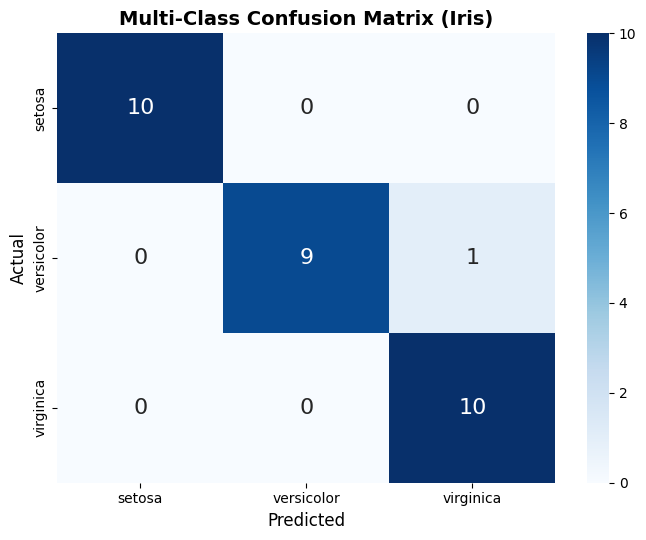


Classification Report (per-class and averaged metrics):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Multi-class ROC-AUC (macro, One-vs-Rest): 0.9717


In [25]:
# Load and explore the Iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
iris_names = iris.target_names

print(f"Iris Dataset: {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"Features: {', '.join(iris.feature_names)}")
print(f"Classes: {', '.join(iris_names)}")
print(f"Distribution: {dict(zip(*np.unique(y_iris, return_counts=True)))}")
print(f"\nThis is a balanced dataset: each class has exactly 50 samples.")

# Split data
X_ir_tr, X_ir_te, y_ir_tr, y_ir_te = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

# Train Decision Tree and make predictions
iris_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
iris_dt.fit(X_ir_tr, y_ir_tr)
y_ir_pred = iris_dt.predict(X_ir_te)
y_ir_proba = iris_dt.predict_proba(X_ir_te)

print(f"\nPrediction probabilities shape: {y_ir_proba.shape}")
print(f"(Each row has 3 probabilities -- one per class -- summing to 1.0)")
print(f"\nExample -- first test sample:")
print(f"  Probabilities: {np.round(y_ir_proba[0], 3)}")
print(f"  Predicted class: {iris_names[y_ir_pred[0]]}")
print(f"  True class:      {iris_names[y_ir_te[0]]}")

# Multi-class confusion matrix
iris_cm = confusion_matrix(y_ir_te, y_ir_pred)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(iris_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris_names, yticklabels=iris_names,
            annot_kws={'size': 16}, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Multi-Class Confusion Matrix (Iris)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report (per-class and averaged metrics):")
print(classification_report(y_ir_te, y_ir_pred, target_names=iris_names))

# Multi-class ROC-AUC
y_ir_bin = label_binarize(y_ir_te, classes=[0, 1, 2])
iris_auc = roc_auc_score(y_ir_bin, y_ir_proba, average='macro', multi_class='ovr')
print(f"Multi-class ROC-AUC (macro, One-vs-Rest): {iris_auc:.4f}")


### Exercise 4.1: Multi-Class Pipeline

Build a complete multi-class classification and evaluation pipeline. This exercise combines everything you have learned: training a model, generating predictions and probabilities, and computing a comprehensive set of evaluation metrics.

**Key hints:**
- `predict_proba()` returns shape (n_samples, n_classes) -- do NOT index with `[:, 1]` for multi-class
- Use `average='macro'` for macro averaging, `average='weighted'` for weighted
- Use `average=None` to get per-class arrays (one value per class)
- The confusion matrix call is the same: `confusion_matrix(y_test, predictions)`


In [26]:
def multiclass_pipeline(X_train, y_train, X_test, y_test, class_names, max_depth=4):
    """
    Complete multi-class classification pipeline.

    Returns dict with keys:
        'model': fitted DecisionTreeClassifier (criterion='gini', random_state=42)
        'predictions': predicted labels for X_test
        'probabilities': predict_proba output (n_samples x n_classes)
        'accuracy': float
        'macro_precision': float (average='macro')
        'macro_recall': float (average='macro')
        'macro_f1': float (average='macro')
        'weighted_f1': float (average='weighted')
        'per_class_precision': array from precision_score(average=None)
        'per_class_recall': array from recall_score(average=None)
        'confusion_matrix': numpy array
    """
    result = {}

    # Step 1: Create and train a DecisionTreeClassifier
    model = DecisionTreeClassifier(criterion='gini', max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    result['model'] = model

    # Step 2: Generate predictions and probabilities
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)
    result['predictions'] = predictions
    result['probabilities'] = probabilities

    # Step 3: Compute overall metrics
    result['accuracy'] = accuracy_score(y_test, predictions)
    result['macro_precision'] = precision_score(y_test, predictions, average='macro')
    result['macro_recall'] = recall_score(y_test, predictions, average='macro')
    result['macro_f1'] = f1_score(y_test, predictions, average='macro')
    result['weighted_f1'] = f1_score(y_test, predictions, average='weighted')

    # Step 4: Compute per-class metrics (average=None)
    result['per_class_precision'] = precision_score(y_test, predictions, average=None)
    result['per_class_recall'] = recall_score(y_test, predictions, average=None)

    # Step 5: Compute confusion matrix
    result['confusion_matrix'] = confusion_matrix(y_test, predictions)

    return result

# Test
pipe = multiclass_pipeline(X_ir_tr, y_ir_tr, X_ir_te, y_ir_te, iris_names.tolist())
if pipe['accuracy'] is not None:
    print(f"Accuracy: {pipe['accuracy']:.4f}, Macro F1: {pipe['macro_f1']:.4f}")
    if pipe['per_class_precision'] is not None:
        for i, n in enumerate(iris_names):
            print(f"  {n}: Precision={pipe['per_class_precision'][i]:.3f}, "
                  f"Recall={pipe['per_class_recall'][i]:.3f}")


Accuracy: 0.9333, Macro F1: 0.9333
  setosa: Precision=1.000, Recall=1.000
  versicolor: Precision=0.900, Recall=0.900
  virginica: Precision=0.900, Recall=0.900


In [27]:
# ============================================================
# TESTER for Exercise 4.1 (DO NOT MODIFY)
# ============================================================

def test_exercise_4_1():
    score = 0
    total = 20
    r = multiclass_pipeline(X_ir_tr, y_ir_tr, X_ir_te, y_ir_te, iris_names.tolist())

    if isinstance(r.get('model'), DecisionTreeClassifier):
        score += 2; print("✅ Model is DecisionTreeClassifier")
    else:
        print("❌ Model type incorrect")
    if r.get('predictions') is not None and len(r['predictions']) == len(y_ir_te):
        score += 2; print(f"✅ Predictions shape: {len(r['predictions'])}")
    else:
        print("❌ Predictions shape incorrect")
    if r.get('probabilities') is not None and r['probabilities'].shape == (len(y_ir_te), 3):
        score += 2; print(f"✅ Probabilities shape: {r['probabilities'].shape}")
    else:
        print("❌ Probabilities shape incorrect")
    if r.get('probabilities') is not None and np.allclose(r['probabilities'].sum(axis=1), 1.0):
        score += 2; print("✅ Probabilities sum to 1.0 per sample")
    else:
        print("❌ Probabilities don't sum to 1.0")
    if r.get('accuracy') is not None and r['accuracy'] > 0.85:
        score += 2; print(f"✅ Accuracy = {r['accuracy']:.4f}")
    else:
        print(f"❌ Accuracy too low: {r.get('accuracy')}")
    if r.get('predictions') is not None:
        exp_mp = precision_score(y_ir_te, r['predictions'], average='macro')
        exp_mr = recall_score(y_ir_te, r['predictions'], average='macro')
        exp_mf = f1_score(y_ir_te, r['predictions'], average='macro')
        ok = (r.get('macro_precision') is not None and abs(r['macro_precision'] - exp_mp) < 1e-4
              and r.get('macro_recall') is not None and abs(r['macro_recall'] - exp_mr) < 1e-4
              and r.get('macro_f1') is not None and abs(r['macro_f1'] - exp_mf) < 1e-4)
        if ok:
            score += 3; print("✅ Macro metrics correct")
        else:
            print("❌ Macro metrics incorrect")
    if r.get('predictions') is not None:
        exp_wf = f1_score(y_ir_te, r['predictions'], average='weighted')
        if r.get('weighted_f1') is not None and abs(r['weighted_f1'] - exp_wf) < 1e-4:
            score += 1; print(f"✅ Weighted F1 = {r['weighted_f1']:.4f}")
        else:
            print("❌ Weighted F1 incorrect")
    if r.get('predictions') is not None:
        exp_pcp = precision_score(y_ir_te, r['predictions'], average=None)
        if r.get('per_class_precision') is not None and len(r['per_class_precision']) == 3:
            if np.allclose(r['per_class_precision'], exp_pcp, atol=1e-4):
                score += 2; print("✅ Per-class precision correct")
            else:
                score += 1; print("❌ Per-class precision: right shape, wrong values")
        else:
            print("❌ Per-class precision incorrect")
    if r.get('predictions') is not None:
        exp_pcr = recall_score(y_ir_te, r['predictions'], average=None)
        if r.get('per_class_recall') is not None and len(r['per_class_recall']) == 3:
            if np.allclose(r['per_class_recall'], exp_pcr, atol=1e-4):
                score += 2; print("✅ Per-class recall correct")
            else:
                score += 1; print("❌ Per-class recall: right shape, wrong values")
        else:
            print("❌ Per-class recall incorrect")
    if r.get('predictions') is not None:
        exp_cm = confusion_matrix(y_ir_te, r['predictions'])
        if r.get('confusion_matrix') is not None and np.array_equal(r['confusion_matrix'], exp_cm):
            score += 2; print("✅ Confusion matrix correct")
        else:
            print("❌ Confusion matrix incorrect")
    score = min(score, total)
    print(f"\n{'='*40}\nExercise 4.1 Score: {score}/{total}\n{'='*40}")
    return score

ex4_1_score = test_exercise_4_1()


✅ Model is DecisionTreeClassifier
✅ Predictions shape: 30
✅ Probabilities shape: (30, 3)
✅ Probabilities sum to 1.0 per sample
✅ Accuracy = 0.9333
✅ Macro metrics correct
✅ Weighted F1 = 0.9333
✅ Per-class precision correct
✅ Per-class recall correct
✅ Confusion matrix correct

Exercise 4.1 Score: 20/20


---
## Part 5: Summary & Final Score (15 points)

### Classification Metrics Cheat Sheet

| Metric | Formula | Best When... |
|--------|---------|-------------|
| **Accuracy** | (TP+TN) / Total | Balanced classes, equal error costs |
| **Precision** | TP / (TP+FP) | False positives are costly (spam filter, fraud alerts) |
| **Recall** | TP / (TP+FN) | False negatives are costly (cancer detection, security) |
| **F1-Score** | Harmonic mean of P & R | Need single metric balancing both P and R |
| **Specificity** | TN / (TN+FP) | Need to measure negative class detection rate |
| **ROC-AUC** | Area under ROC curve | Threshold-independent model comparison |

### Key Takeaways

**Decision Trees:** Split data using feature thresholds to maximize class purity. Easy to interpret and visualize, but prone to overfitting without depth limits. Feature importance reveals which variables drive predictions.

**Accuracy is misleading** with imbalanced classes. A model that always predicts the majority class can achieve high accuracy while being completely useless for detecting the minority class. Always examine precision, recall, and F1.

**Threshold tuning** gives you control over the precision-recall tradeoff. Lower thresholds increase recall at the cost of precision; higher thresholds do the opposite. The optimal threshold depends on the relative costs of false positives vs. false negatives in your specific application.

**Multi-class metrics** require careful attention to averaging. Macro average treats all classes equally; weighted average accounts for class imbalance. Per-class metrics reveal which specific classes the model struggles with.

**ROC-AUC** provides a threshold-independent measure of how well the model separates classes. An AUC of 1.0 means perfect separation; 0.5 means random guessing.

### Further Reading
- [Google ML Crash Course: Classification](https://developers.google.com/machine-learning/crash-course/classification)
- [Google ML Crash Course: ROC & AUC](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc)
- [Scikit-learn: Decision Trees](https://scikit-learn.org/stable/modules/tree.html)
- [Scikit-learn: Classification Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html)


In [28]:
# ============================================================
# FINAL SCORE SUMMARY
# ============================================================

print("=" * 60)
print("FINAL LAB SCORE SUMMARY")
print("=" * 60)

scores = {}
for name, var in [('Ex 1.1 - Data Exploration', 'ex1_1_score'),
                   ('Ex 1.2 - Feature Analysis', 'ex1_2_score'),
                   ('Ex 2.1 - Train & Predict', 'ex2_1_score'),
                   ('Ex 3.1 - Manual Metrics', 'ex3_1_score'),
                   ('Ex 3.2 - Threshold Analysis', 'ex3_2_score'),
                   ('Ex 3.3 - Full Evaluation', 'ex3_3_score'),
                   ('Ex 4.1 - Multi-Class Pipeline', 'ex4_1_score')]:
    try:
        scores[name] = eval(var)
    except:
        scores[name] = 0

maxes = {'Ex 1.1 - Data Exploration': 5, 'Ex 1.2 - Feature Analysis': 10,
         'Ex 2.1 - Train & Predict': 20, 'Ex 3.1 - Manual Metrics': 10,
         'Ex 3.2 - Threshold Analysis': 10, 'Ex 3.3 - Full Evaluation': 10,
         'Ex 4.1 - Multi-Class Pipeline': 20}

participation = 15
print(f"\n{'Exercise':<40} {'Score':<8} {'Max'}")
print("-" * 60)
for name in scores:
    s, m = scores[name], maxes[name]
    icon = "✅" if s == m else "❌"
    print(f"{icon} {name:<38} {s:<8} {m}")
print(f"  {'Reading & Participation':<38} {participation:<8} 15")
print("-" * 60)
total = sum(scores.values()) + participation
total_max = sum(maxes.values()) + 15
print(f"{'TOTAL':<40} {total:<8} {total_max}")
print(f"Percentage: {total/total_max*100:.1f}%")


FINAL LAB SCORE SUMMARY

Exercise                                 Score    Max
------------------------------------------------------------
✅ Ex 1.1 - Data Exploration              5        5
✅ Ex 1.2 - Feature Analysis              10       10
✅ Ex 2.1 - Train & Predict               20       20
✅ Ex 3.1 - Manual Metrics                10       10
✅ Ex 3.2 - Threshold Analysis            10       10
✅ Ex 3.3 - Full Evaluation               10       10
✅ Ex 4.1 - Multi-Class Pipeline          20       20
  Reading & Participation                15       15
------------------------------------------------------------
TOTAL                                    100      100
Percentage: 100.0%


---

## Reflection Questions (Part of Participation)

Answer in a separate document or D2L submission:

1. **Why might accuracy be misleading for cancer diagnosis?** Give a specific numerical example showing how a model can have high accuracy yet fail to detect most cancer cases.

2. **In breast cancer detection, which is more important: precision or recall?** Discuss the real-world consequences of false positives vs. false negatives for both patients and the healthcare system.

3. **How does `max_depth` affect Decision Tree performance?** Explain what happens when it is too low (underfitting) vs. too high (overfitting), and how you would choose an appropriate value.

4. **Explain the difference between macro and weighted averaging.** Give an example scenario where they would produce significantly different results and explain which you would prefer in that scenario.

5. **What does an ROC-AUC of 0.95 vs. 0.55 mean practically?** Describe what each value tells you about the model's ability to distinguish between classes.

---


*Reference: [Google ML Crash Course -- Classification](https://developers.google.com/machine-learning/crash-course/classification)*
